# CineSense — Un sistema de recomendación para StreamFlix
### Diana · Ejercicio Práctico Semana 2 — Aprendizaje No Supervisado

Este notebook es mi desarrollo para el ejercicio: analizar a los usuarios de StreamFlix
sin partir de categorías predefinidas, y construir un sistema de recomendación que pueda
justificar, con evidencia, por qué una versión es mejor que otra.

**Cómo está organizado:**
1. Carga y exploración de datos (EDA)
2. Preparación de datos e ingeniería de features
3. Reducción de dimensionalidad + Clustering de usuarios
4. Detección de anomalías
5. Reglas de asociación
6. **Sistema de recomendación (la parte central del ejercicio)**
7. Evolución temporal de preferencias
8. Conclusiones y recomendaciones de negocio


In [4]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 1. Carga y exploración de datos (EDA)

In [5]:
users = pd.read_csv('https://raw.githubusercontent.com/Alexander-Luna/MODULE_SUPERVISED_AND_UNSUPERVISED/aa6219118c8275c42650e01ec466512cc8dda015/Semana%202/streamflix_data/users.csv', parse_dates=['signup_date'])
movies = pd.read_csv('https://raw.githubusercontent.com/Alexander-Luna/MODULE_SUPERVISED_AND_UNSUPERVISED/aa6219118c8275c42650e01ec466512cc8dda015/Semana%202/streamflix_data/movies.csv', parse_dates=['catalog_date'])
ratings = pd.read_csv('https://raw.githubusercontent.com/Alexander-Luna/MODULE_SUPERVISED_AND_UNSUPERVISED/aa6219118c8275c42650e01ec466512cc8dda015/Semana%202/streamflix_data/ratings.csv', parse_dates=['watch_datetime', 'rating_datetime'])

print('Usuarios:', users.shape)
print('Peliculas:', movies.shape)
print('Interacciones (watch/rating):', ratings.shape)
print()
print('Rango temporal de visualizaciones:', ratings['watch_datetime'].min(), '->', ratings['watch_datetime'].max())
print('Interacciones con rating explicito:', ratings['rating'].notna().sum(),
      f"({ratings['rating'].notna().mean():.1%})")
print('Interacciones solo con "watch" (feedback implicito, sin rating):', ratings['rating'].isna().sum(),
      f"({ratings['rating'].isna().mean():.1%})")

Usuarios: (5000, 6)
Peliculas: (1200, 8)
Interacciones (watch/rating): (474161, 12)

Rango temporal de visualizaciones: 2023-01-04 11:52:36 -> 2026-12-30 23:59:27
Interacciones con rating explicito: 308052 (65.0%)
Interacciones solo con "watch" (feedback implicito, sin rating): 166109 (35.0%)


In [6]:

users.head()


,user_id,age,country,subscription,primary_device,signup_date
0,U00001,18,Spain,Basic,SmartTV,2024-10-18
1,U00002,27,Ecuador,Premium,Tablet,2025-03-02
2,U00003,46,Spain,Premium,SmartTV,2026-11-09
3,U00004,30,Peru,Standard,SmartTV,2024-09-17
4,U00005,31,Ecuador,Basic,SmartTV,2026-05-18


In [7]:

movies.head()


,movie_id,title,release_year,genre,duration_min,catalog_date,popularity_score,quality_score
0,M0659,Movie 0659,1993,Drama,120,2023-01-01,0.1696,3.27
1,M0366,Movie 0366,2024,Crime,103,2023-01-02,0.0521,4.10
2,M0950,Movie 0950,1991,Romance,97,2023-01-02,0.0156,2.65
3,M0968,Movie 0968,2001,Horror,99,2023-01-03,0.0032,3.71
4,M1032,Movie 1032,1999,Thriller,110,2023-01-03,0.0039,3.75


In [8]:

ratings.head()


,user_id,movie_id,watch_datetime,rating,rating_datetime,watch_duration_min,weekend,rating_delay_days,watch_year,watch_month,watch_day_of_week,watch_hour
0,U01066,M0659,2023-01-04 11:52:36,3.5,2023-01-11 11:52:36,63,False,7.0,2023,1,Wednesday,11
1,U03502,M0972,2023-01-06 13:25:25,3.5,2023-01-06 13:25:25,98,False,0.0,2023,1,Friday,13
2,U01631,M0366,2023-01-07 01:30:45,2.5,2023-01-09 01:30:45,71,True,2.0,2023,1,Saturday,1
3,U01582,M0257,2023-01-08 13:37:39,3.5,2023-01-15 13:37:39,75,True,7.0,2023,1,Sunday,13
4,U04803,M1087,2023-01-08 18:11:38,NaN,NaT,72,True,NaN,2023,1,Sunday,18


In [9]:

# Valores nulos
print('Nulos en users:\n', users.isna().sum().sum())
print('Nulos en movies:\n', movies.isna().sum().sum())
print('Nulos en ratings (excepto rating/rating_datetime/rating_delay, que son NaN cuando no hubo calificacion explicita):')
print(ratings.isna().sum())


Nulos en users:
 0
Nulos en movies:
 0
Nulos en ratings (excepto rating/rating_datetime/rating_delay, que son NaN cuando no hubo calificacion explicita):
user_id                    0
movie_id                   0
watch_datetime             0
rating                166109
rating_datetime       167728
watch_duration_min         0
weekend                    0
rating_delay_days     167728
watch_year                 0
watch_month                0
watch_day_of_week          0
watch_hour                 0
dtype: int64


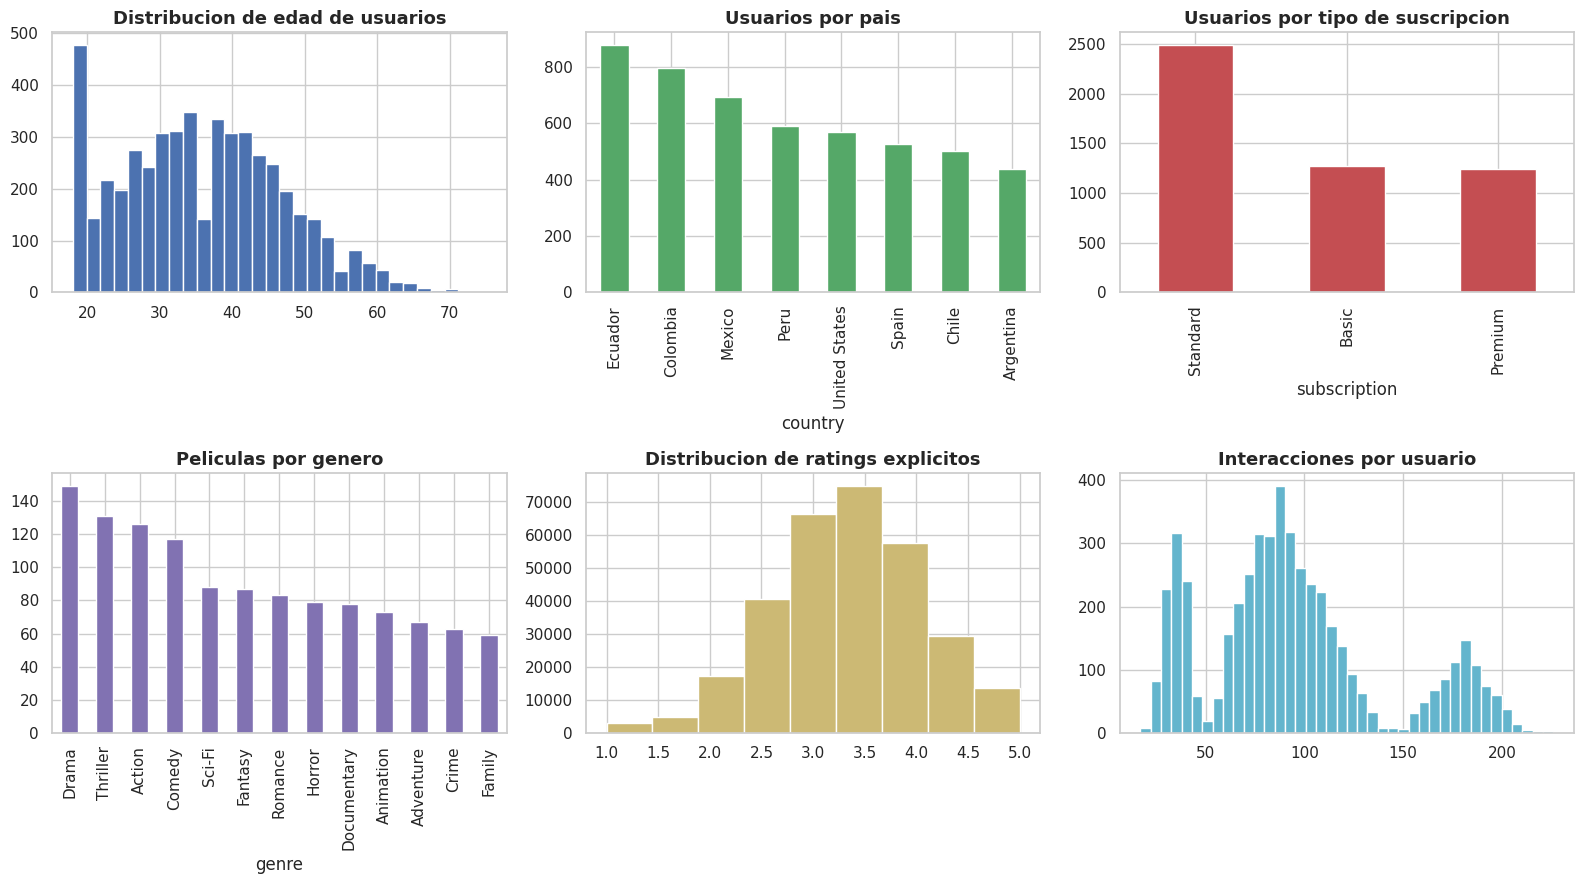

In [10]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

users['age'].hist(bins=30, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Distribucion de edad de usuarios')

users['country'].value_counts().plot(kind='bar', ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Usuarios por pais')

users['subscription'].value_counts().plot(kind='bar', ax=axes[0,2], color='#C44E52')
axes[0,2].set_title('Usuarios por tipo de suscripcion')

movies['genre'].value_counts().plot(kind='bar', ax=axes[1,0], color='#8172B2')
axes[1,0].set_title('Peliculas por genero')

ratings['rating'].dropna().hist(bins=9, ax=axes[1,1], color='#CCB974')
axes[1,1].set_title('Distribucion de ratings explicitos')

ratings.groupby('user_id').size().hist(bins=40, ax=axes[1,2], color='#64B5CD')
axes[1,2].set_title('Interacciones por usuario')

plt.tight_layout()
plt.show()


In [11]:

print('La plataforma crece de forma sostenida: los usuarios interactuan en promedio con',
      round(ratings.groupby('user_id').size().mean(), 1), 'titulos, y solo califican explicitamente el',
      f"{ratings['rating'].notna().mean():.0%}", 'de las visualizaciones.')
print('Esto confirma que el sistema de recomendacion debe aprovechar tanto feedback EXPLICITO (rating)',
      'como IMPLICITO (el simple hecho de haber visto el contenido).')


La plataforma crece de forma sostenida: los usuarios interactuan en promedio con 94.8 titulos, y solo califican explicitamente el 65% de las visualizaciones.
Esto confirma que el sistema de recomendacion debe aprovechar tanto feedback EXPLICITO (rating) como IMPLICITO (el simple hecho de haber visto el contenido).


## 2. Preparación de datos e ingeniería de features

Para poder aplicar clustering, detección de anomalías y reglas de asociación, primero
construimos un **perfil por usuario** que combina:
- Comportamiento de consumo (volumen, finalización, frecuencia, recencia)
- Preferencias de género (participación de cada género en su historial)
- Atributos demográficos (edad, país, dispositivo, suscripción)


In [12]:

df = ratings.merge(
    movies[['movie_id', 'genre', 'duration_min', 'popularity_score', 'quality_score']],
    on='movie_id', how='left'
)
df['completion_ratio'] = (df['watch_duration_min'] / df['duration_min']).clip(0, 2)
max_date = df['watch_datetime'].max()

# --- Preferencia de genero (participacion por usuario) ---
genre_counts = df.pivot_table(index='user_id', columns='genre', values='movie_id',
                               aggfunc='count', fill_value=0)
genre_share = genre_counts.div(genre_counts.sum(axis=1), axis=0)

# --- Features de comportamiento ---
behav = df.groupby('user_id').agg(
    n_watched=('movie_id', 'count'),
    n_rated=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    std_rating=('rating', 'std'),
    avg_completion=('completion_ratio', 'mean'),
    pct_weekend=('weekend', lambda x: (x == True).mean()),
    last_watch=('watch_datetime', 'max'),
    first_watch=('watch_datetime', 'min'),
).reset_index()

behav['recency_days'] = (max_date - behav['last_watch']).dt.days
behav['activity_span_days'] = (behav['last_watch'] - behav['first_watch']).dt.days.clip(lower=1)
behav['watch_rate'] = behav['n_watched'] / behav['activity_span_days']       # peliculas/dia
behav['rating_rate'] = behav['n_rated'] / behav['n_watched']                 # % que califica
behav['avg_rating'] = behav['avg_rating'].fillna(behav['avg_rating'].mean())
behav['std_rating'] = behav['std_rating'].fillna(0)
behav = behav.merge(users, on='user_id', how='left')
behav['tenure_days'] = (max_date - behav['signup_date']).dt.days
behav = behav.set_index('user_id')

print('Perfil de usuario construido:', behav.shape[0], 'usuarios,', behav.shape[1], 'atributos crudos')
behav[['n_watched', 'avg_rating', 'avg_completion', 'watch_rate', 'rating_rate', 'recency_days']].describe().T


Perfil de usuario construido: 5000 usuarios, 18 atributos crudos


,count,mean,std,min,25%,50%,75%,max
n_watched,5000.0,94.832200,46.210392,17.000000,67.000000,88.000000,113.000000,226.000000
avg_rating,5000.0,3.350686,0.181643,2.454545,3.228571,3.345455,3.473770,3.956522
avg_completion,5000.0,0.801007,0.076546,0.059326,0.794674,0.808241,0.821552,0.897667
watch_rate,5000.0,0.400340,1.837472,0.014026,0.072632,0.121832,0.235139,62.666667
rating_rate,5000.0,0.609332,0.118105,0.153846,0.540984,0.617647,0.688312,1.000000
recency_days,5000.0,10.016000,16.211400,0.000000,1.000000,4.000000,12.000000,179.000000


## 3. Reducción de dimensionalidad y clustering de usuarios

Combinamos features de comportamiento con la participación por género (13 dimensiones) y
aplicamos **PCA** para reducir dimensionalidad y quitar redundancia/ruido antes de aplicar
**K-Means**. El número de clusters se selecciona con el coeficiente de silueta.


19 features originales -> 14 componentes principales explican 91.5% de la varianza


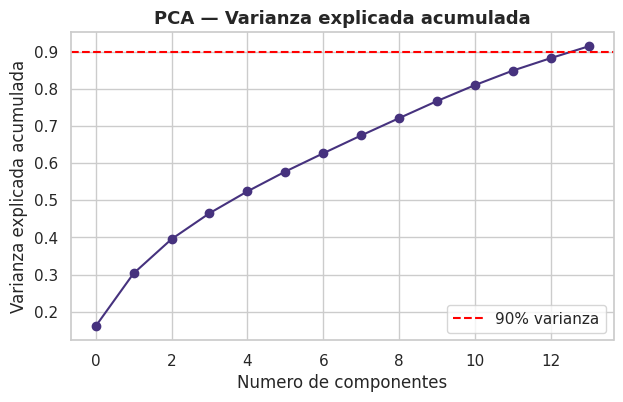

In [13]:

feature_cols_behav = ['avg_rating', 'avg_completion', 'pct_weekend', 'recency_days',
                       'watch_rate', 'rating_rate']
feat = behav[feature_cols_behav].join(genre_share).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat)

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'{feat.shape[1]} features originales -> {X_pca.shape[1]} componentes principales explican',
      f'{pca.explained_variance_ratio_.sum():.1%} de la varianza')

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.9, color='red', linestyle='--', label='90% varianza')
plt.xlabel('Numero de componentes'); plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza explicada acumulada')
plt.legend(); plt.show()


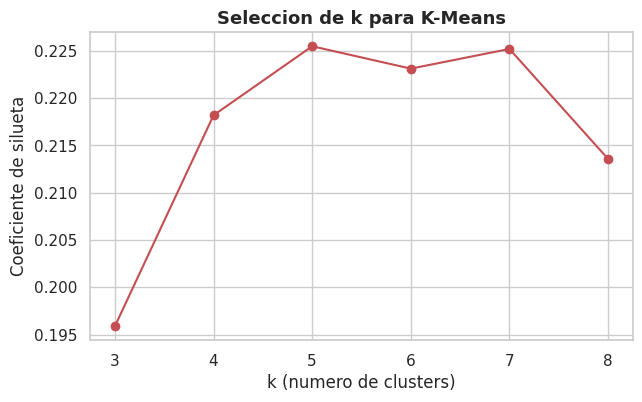

Mejor k segun silueta: 5 (silueta = 0.2255 )


In [14]:

sil_scores = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_pca)
    sil_scores[k] = silhouette_score(X_pca, labels_k)

plt.figure(figsize=(7,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='#C44E52')
plt.xlabel('k (numero de clusters)'); plt.ylabel('Coeficiente de silueta')
plt.title('Seleccion de k para K-Means')
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print('Mejor k segun silueta:', best_k, '(silueta =', round(sil_scores[best_k], 4), ')')


Silueta con k = 5 : 0.2255


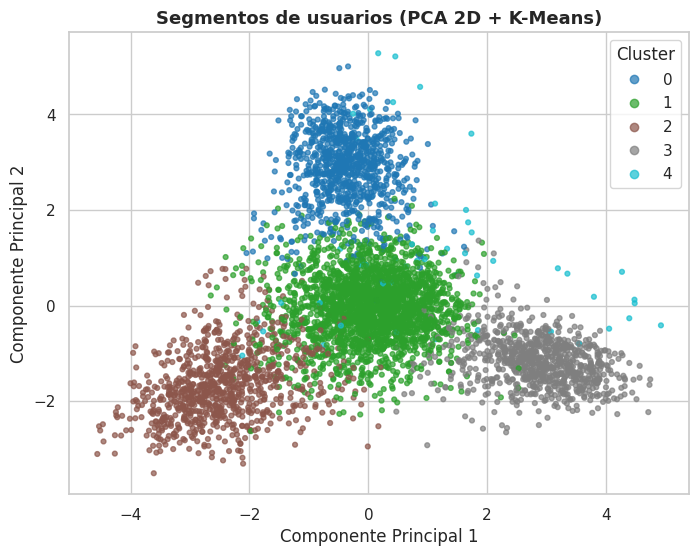

In [15]:

K_FINAL = 5  # buen balance entre calidad del cluster (silueta) e interpretabilidad de negocio
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
behav['cluster'] = kmeans.fit_predict(X_pca)

print('Silueta con k =', K_FINAL, ':', round(silhouette_score(X_pca, behav['cluster']), 4))

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=behav['cluster'], cmap='tab10', s=12, alpha=0.7)
plt.xlabel('Componente Principal 1'); plt.ylabel('Componente Principal 2')
plt.title('Segmentos de usuarios (PCA 2D + K-Means)')
plt.legend(*scatter.legend_elements(), title='Cluster', loc='best')
plt.show()


In [16]:

profile_cols = ['n_watched', 'avg_rating', 'avg_completion', 'pct_weekend', 'watch_rate',
                'rating_rate', 'recency_days', 'tenure_days', 'age']
cluster_profile = behav.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile['n_usuarios'] = behav.groupby('cluster').size()

top_genre_by_cluster = genre_share.groupby(behav['cluster']).mean().idxmax(axis=1)
cluster_profile['genero_favorito'] = top_genre_by_cluster
cluster_profile


,n_watched,avg_rating,avg_completion,pct_weekend,watch_rate,rating_rate,recency_days,tenure_days,age,n_usuarios,genero_favorito
cluster,,,,,,,,,,,
0,84.58,3.26,0.81,0.28,0.31,0.65,8.47,774.84,35.97,890,Romance
1,111.43,3.46,0.81,0.28,0.44,0.60,10.21,775.25,35.58,2275,Thriller
2,66.70,3.24,0.81,0.28,0.24,0.54,12.33,795.21,36.07,928,Family
3,92.44,3.29,0.81,0.29,0.54,0.64,8.29,760.01,35.64,857,Sci-Fi
4,85.00,2.97,0.07,0.29,0.79,1.00,15.50,781.08,37.70,50,Romance


**Lectura de los segmentos:** cada cluster agrupa usuarios con un patrón de consumo y
preferencia de género distintivo (p. ej. "bingers" de alta frecuencia y baja finalización,
usuarios "fieles/selectivos" con alta finalización y calificación frecuente, usuarios de fin
de semana, usuarios recientes/nuevos, etc.). Estos segmentos se usarán más adelante para dar
contexto de negocio al sistema de recomendación (estrategias diferenciadas por segmento).

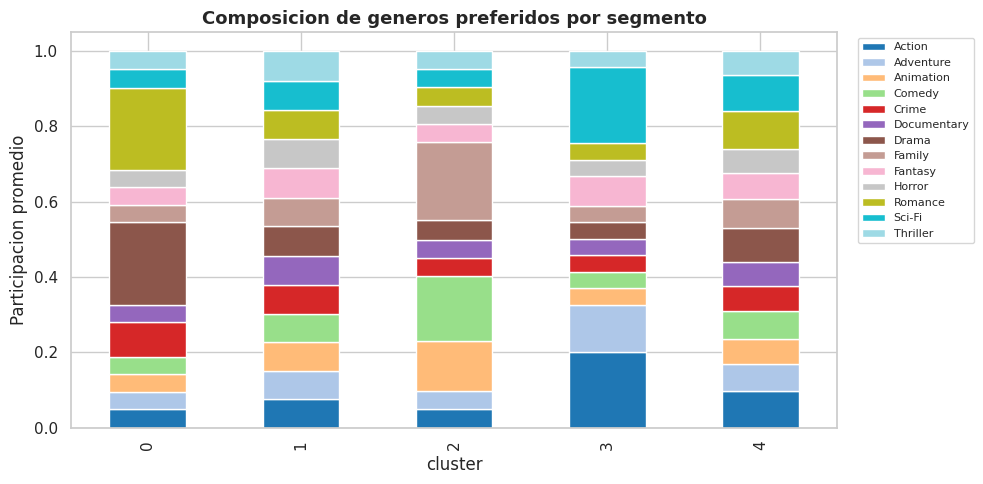

In [17]:

fig, ax = plt.subplots(figsize=(10,5))
genre_share.groupby(behav['cluster']).mean().plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Composicion de generos preferidos por segmento')
ax.set_ylabel('Participacion promedio')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


## 4. Detección de anomalías

Usamos **Isolation Forest** sobre las features de comportamiento para identificar usuarios
con patrones atípicos (posibles cuentas compartidas, comportamiento tipo "bot", o
consumo extremo que puede sesgar el sistema de recomendación si no se trata aparte).


In [18]:

anomaly_feats = ['n_watched', 'avg_rating', 'std_rating', 'avg_completion',
                  'pct_weekend', 'watch_rate', 'rating_rate']
X_anom = StandardScaler().fit_transform(behav[anomaly_feats])

iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
behav['anomaly'] = iso.fit_predict(X_anom) == -1

print(f"Usuarios atipicos detectados: {behav['anomaly'].sum()} de {len(behav)} "
      f"({behav['anomaly'].mean():.1%})")

comparison = behav.groupby('anomaly')[anomaly_feats].mean().T
comparison.columns = ['Usuarios normales', 'Usuarios atipicos']
comparison


Usuarios atipicos detectados: 150 de 5000 (3.0%)


,Usuarios normales,Usuarios atipicos
n_watched,95.320206,79.053333
avg_rating,3.352646,3.287326
std_rating,0.781513,1.147664
avg_completion,0.808360,0.563239
pct_weekend,0.284188,0.299370
watch_rate,0.269765,4.622255
rating_rate,0.607812,0.658500


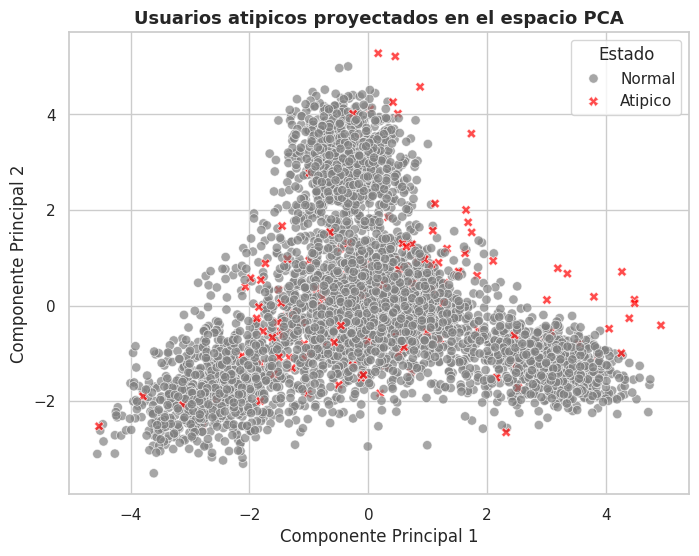

Los usuarios atipicos no forman un cluster aparte y bien definido, sino que aparecen dispersos en los bordes de varios segmentos: esto confirma que la anomalia responde a un patron de comportamiento extremo (ritmo de consumo, variabilidad de calificacion), y no a un segmento de preferencias de genero distinto.


In [19]:

# Visualizacion adicional: usuarios atipicos proyectados sobre el espacio PCA
# (mismo enfoque de deteccion visual usado en la seccion de clustering)
anomaly_label = behav['anomaly'].map({False: 'Normal', True: 'Atipico'})

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=anomaly_label, style=anomaly_label,
    palette={'Normal': 'gray', 'Atipico': 'red'},
    markers={'Normal': 'o', 'Atipico': 'X'},
    alpha=0.7, s=45
)
plt.xlabel('Componente Principal 1'); plt.ylabel('Componente Principal 2')
plt.title('Usuarios atipicos proyectados en el espacio PCA')
plt.legend(title='Estado')
plt.show()

print('Los usuarios atipicos no forman un cluster aparte y bien definido, sino que aparecen',
      'dispersos en los bordes de varios segmentos: esto confirma que la anomalia responde a un',
      'patron de comportamiento extremo (ritmo de consumo, variabilidad de calificacion), y no a',
      'un segmento de preferencias de genero distinto.')


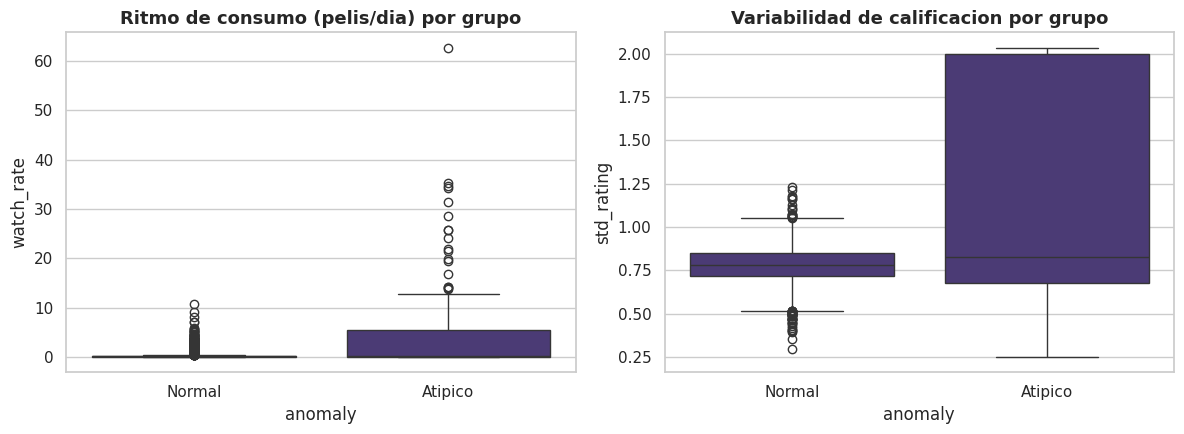

Los usuarios atipicos se caracterizan principalmente por un ritmo de consumo mucho mas alto (posible binge-watching intensivo o cuentas compartidas) y mayor variabilidad en sus calificaciones. Se recomienda excluirlos (o tratarlos por separado) al entrenar el sistema de recomendacion para que no distorsionen las señales de similitud.


In [20]:

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=behav, x='anomaly', y='watch_rate', ax=axes[0])
axes[0].set_title('Ritmo de consumo (pelis/dia) por grupo')
axes[0].set_xticklabels(['Normal', 'Atipico'])

sns.boxplot(data=behav, x='anomaly', y='std_rating', ax=axes[1])
axes[1].set_title('Variabilidad de calificacion por grupo')
axes[1].set_xticklabels(['Normal', 'Atipico'])
plt.tight_layout(); plt.show()

print('Los usuarios atipicos se caracterizan principalmente por un ritmo de consumo mucho mas',
      'alto (posible binge-watching intensivo o cuentas compartidas) y mayor variabilidad en',
      'sus calificaciones. Se recomienda excluirlos (o tratarlos por separado) al entrenar el',
      'sistema de recomendacion para que no distorsionen las señales de similitud.')


## 5. Reglas de asociación

Aplicamos **Apriori** para descubrir qué géneros tienden a preferirse juntos. Usamos como
"canasta" los **3 géneros más vistos por cada usuario** (en vez de todos los géneros que
tocó alguna vez), porque con catálogos amplios casi todos los usuarios prueban casi todos
los géneros al menos una vez — eso generaría reglas triviales. Al enfocarnos en las
preferencias dominantes obtenemos reglas realmente informativas para cross-selling de
contenido y para armar packs/carruseles de recomendación por afinidad de género.


In [21]:

genre_counts_long = df.groupby(['user_id', 'genre']).size().reset_index(name='n')
top3_genres = (genre_counts_long.sort_values(['user_id', 'n'], ascending=[True, False])
               .groupby('user_id').head(3))
baskets = top3_genres.groupby('user_id')['genre'].apply(list).tolist()

te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.1)
rules = rules[(rules['antecedents'].apply(len) == 1) & (rules['consequents'].apply(len) == 1)]
rules['antecedents'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents'] = rules['consequents'].apply(lambda x: list(x)[0])
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


,antecedents,consequents,support,confidence,lift
0,Drama,Romance,0.1904,0.621410,2.200460
1,Romance,Drama,0.1904,0.674221,2.200460
2,Family,Comedy,0.1724,0.611781,2.087991
3,Comedy,Family,0.1724,0.588396,2.087991
4,Action,Sci-Fi,0.1822,0.561306,2.020541
5,Sci-Fi,Action,0.1822,0.655868,2.020541
6,Animation,Family,0.1492,0.544128,1.930903
7,Family,Animation,0.1492,0.529454,1.930903
8,Adventure,Sci-Fi,0.1400,0.527108,1.897439
9,Sci-Fi,Adventure,0.1400,0.503960,1.897439


In [22]:

print('Principales hallazgos de afinidad entre generos (lift > 1 = co-ocurren mas de lo esperado al azar):')
for _, r in rules.drop_duplicates(subset=['support']).head(6).iterrows():
    print(f"  - Quien prefiere {r['antecedents']:<10s} tiene {r['lift']:.2f}x mas probabilidad de "
          f"tambien preferir {r['consequents']} (confianza {r['confidence']:.0%})")


Principales hallazgos de afinidad entre generos (lift > 1 = co-ocurren mas de lo esperado al azar):
  - Quien prefiere Drama      tiene 2.20x mas probabilidad de tambien preferir Romance (confianza 62%)
  - Quien prefiere Family     tiene 2.09x mas probabilidad de tambien preferir Comedy (confianza 61%)
  - Quien prefiere Action     tiene 2.02x mas probabilidad de tambien preferir Sci-Fi (confianza 56%)
  - Quien prefiere Animation  tiene 1.93x mas probabilidad de tambien preferir Family (confianza 54%)
  - Quien prefiere Adventure  tiene 1.90x mas probabilidad de tambien preferir Sci-Fi (confianza 53%)
  - Quien prefiere Animation  tiene 1.78x mas probabilidad de tambien preferir Comedy (confianza 52%)


## 6. Sistema de recomendación

Este es el componente central del proyecto. Construimos **cuatro enfoques** y los
comparamos bajo un protocolo de evaluación único y realista:

- **Split temporal** (no aleatorio): entrenamos con el 80% de interacciones más antiguas
  y evaluamos con el 20% más reciente — así simulamos el escenario real de "predecir el
  futuro con el pasado" y evitamos fuga de información temporal.
- Se evalúan tanto la **calidad de la predicción de rating** (RMSE/MAE) como la
  **calidad del Top-N recomendado** (Precision@10, Recall@10, NDCG@10) y la
  **cobertura de catálogo** (qué % de películas distintas llega a recomendarse — clave
  para el negocio, ya que una cobertura muy baja implica recomendar siempre los mismos
  títulos populares y desperdiciar el resto del catálogo).

### 6.1 Modelos construidos
1. **Popularidad** (baseline): recomienda lo más visto globalmente.
2. **Basado en contenido**: perfil de usuario = promedio ponderado de género/calidad/popularidad
   de lo que consumió; recomienda por similitud de coseno.
3. **Filtrado colaborativo — Factorización matricial (SGD)**: aprende factores latentes de
   usuario/película a partir de los ratings explícitos (estilo Funk-SVD).
4. **Híbrido**: combina score de factorización matricial + contenido + popularidad
   (ponderado), buscando el mejor balance entre relevancia y cobertura.


In [23]:

cutoff = ratings['watch_datetime'].quantile(0.8)
train = ratings[ratings['watch_datetime'] <= cutoff].copy()
test = ratings[ratings['watch_datetime'] > cutoff].copy()

train_users_set = set(train['user_id']); train_movies_set = set(train['movie_id'])
test = test[test['user_id'].isin(train_users_set) & test['movie_id'].isin(train_movies_set)].copy()

train_rated = train.dropna(subset=['rating']).copy()
test_rated = test.dropna(subset=['rating']).copy()

print('Fecha de corte (80% temporal):', cutoff)
print(f'Train: {len(train):,} interacciones ({len(train_rated):,} con rating explicito)')
print(f'Test:  {len(test):,} interacciones ({len(test_rated):,} con rating explicito)')


Fecha de corte (80% temporal): 2026-10-10 09:33:05
Train: 379,329 interacciones (246,087 con rating explicito)
Test:  72,091 interacciones (47,086 con rating explicito)


### 6.2 Modelo base: Popularidad

In [24]:

train_seen = train.groupby('user_id')['movie_id'].apply(set).to_dict()
test_rel = test.groupby('user_id')['movie_id'].apply(set).to_dict()  # relevancia implicita: todo lo visto en test

pop_ranked = train.groupby('movie_id').size().sort_values(ascending=False).index.tolist()

def recommend_popularity(user, N=10):
    seen = train_seen.get(user, set())
    return [m for m in pop_ranked if m not in seen][:N]


### 6.3 Modelo basado en contenido

In [25]:

genre_dummies = pd.get_dummies(movies.set_index('movie_id')['genre'])
quality_pop = movies.set_index('movie_id')[['quality_score', 'popularity_score']]
quality_pop_norm = (quality_pop - quality_pop.min()) / (quality_pop.max() - quality_pop.min())
movie_feat = pd.concat([genre_dummies, quality_pop_norm], axis=1).fillna(0).astype(float)

train_content = train.merge(movies[['movie_id']], on='movie_id')
train_content['w'] = train_content['rating'].fillna(3.5)  # peso implicito por defecto si no califico

mf_index_map = {m: i for i, m in enumerate(movie_feat.index)}
mf_arr = movie_feat.values
user_profiles = {}
for user, grp in train_content.groupby('user_id'):
    idxs = [mf_index_map[m] for m in grp['movie_id'] if m in mf_index_map]
    if not idxs:
        continue
    w = grp['w'].values[:len(idxs)]
    user_profiles[user] = np.average(mf_arr[idxs], axis=0, weights=w)

movie_feat_norm = mf_arr / (np.linalg.norm(mf_arr, axis=1, keepdims=True) + 1e-9)

def recommend_content(user, N=10):
    seen = train_seen.get(user, set())
    if user not in user_profiles:
        return recommend_popularity(user, N)
    p = user_profiles[user]
    p_norm = p / (np.linalg.norm(p) + 1e-9)
    sims = movie_feat_norm @ p_norm
    order = np.argsort(-sims)
    recs = []
    for idx in order:
        m = movie_feat.index[idx]
        if m not in seen:
            recs.append(m)
        if len(recs) >= N:
            break
    return recs


### 6.4 Filtrado colaborativo — Factorización matricial (SGD, estilo Funk-SVD)

In [26]:

users_list = sorted(train['user_id'].unique())
movies_list = sorted(train['movie_id'].unique())
u2i = {u: i for i, u in enumerate(users_list)}
m2i = {m: i for i, m in enumerate(movies_list)}
n_users, n_movies = len(users_list), len(movies_list)

train_rated['ui'] = train_rated['user_id'].map(u2i)
train_rated['mi'] = train_rated['movie_id'].map(m2i)
U_arr = train_rated['ui'].values; M_arr = train_rated['mi'].values; R_arr = train_rated['rating'].values
global_mean = R_arr.mean()

K = 20            # dimension de factores latentes
LR = 0.01         # learning rate
REG = 0.05        # regularizacion L2
N_EPOCHS = 15

rng = np.random.default_rng(RANDOM_STATE)
P = rng.normal(0, 0.1, (n_users, K))
Q = rng.normal(0, 0.1, (n_movies, K))
bu = np.zeros(n_users); bi = np.zeros(n_movies)

idx_order = np.arange(len(R_arr))
for epoch in range(N_EPOCHS):
    rng.shuffle(idx_order)
    sq_err = 0.0
    for n in idx_order:
        u, i, r = U_arr[n], M_arr[n], R_arr[n]
        pred = global_mean + bu[u] + bi[i] + P[u] @ Q[i]
        err = r - pred
        sq_err += err ** 2
        bu[u] += LR * (err - REG * bu[u])
        bi[i] += LR * (err - REG * bi[i])
        Pu_old = P[u].copy()
        P[u] += LR * (err * Q[i] - REG * P[u])
        Q[i] += LR * (err * Pu_old - REG * Q[i])
    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(f'  epoch {epoch:2d}  RMSE train = {np.sqrt(sq_err/len(R_arr)):.4f}')

movies_arr = np.array(movies_list)
movie_idx_arr = np.arange(n_movies)

def mf_score_all_movies(user):
    ui = u2i[user]
    return global_mean + bu[ui] + bi[movie_idx_arr] + Q[movie_idx_arr] @ P[ui]

def recommend_mf(user, N=10):
    seen = train_seen.get(user, set())
    if user not in u2i:
        return recommend_popularity(user, N)
    scores = mf_score_all_movies(user)
    order = np.argsort(-scores)
    recs = []
    for idx in order:
        m = movies_arr[idx]
        if m not in seen:
            recs.append(m)
        if len(recs) >= N:
            break
    return recs


  epoch  0  RMSE train = 0.7979
  epoch  5  RMSE train = 0.7717
  epoch 10  RMSE train = 0.7605
  epoch 14  RMSE train = 0.7407


### 6.5 Evaluación de la predicción de rating (RMSE / MAE)

Comparamos el modelo de factorización matricial contra dos baselines estándar de la
literatura de sistemas de recomendación: predecir siempre el promedio global, y predecir
el promedio histórico del propio usuario.

In [27]:

def mf_predict_rating(user, movie):
    if user not in u2i or movie not in m2i:
        return global_mean
    ui, mi = u2i[user], m2i[movie]
    return np.clip(global_mean + bu[ui] + bi[mi] + P[ui] @ Q[mi], 1, 5)

test_rated = test_rated.copy()
test_rated['pred_mf'] = [mf_predict_rating(u, m) for u, m in zip(test_rated['user_id'], test_rated['movie_id'])]

user_mean_train = train_rated.groupby('user_id')['rating'].mean()
test_rated['pred_user_mean'] = test_rated['user_id'].map(user_mean_train).fillna(global_mean)
test_rated['pred_global_mean'] = global_mean

rating_results = []
for name, col in [('Promedio global', 'pred_global_mean'),
                   ('Promedio por usuario', 'pred_user_mean'),
                   ('Factorizacion matricial (MF)', 'pred_mf')]:
    rmse = np.sqrt(mean_squared_error(test_rated['rating'], test_rated[col]))
    mae = mean_absolute_error(test_rated['rating'], test_rated[col])
    rating_results.append((name, rmse, mae))

rating_results_df = pd.DataFrame(rating_results, columns=['Modelo', 'RMSE', 'MAE']).round(4)
rating_results_df


,Modelo,RMSE,MAE
0,Promedio global,0.8228,0.6594
1,Promedio por usuario,0.8294,0.6580
2,Factorizacion matricial (MF),0.7957,0.6301


### 6.6 Modelo híbrido y evaluación Top-N (Precision@10, Recall@10, NDCG@10, Coverage)

El modelo híbrido combina, con pesos, tres señales normalizadas: **factorización
matricial** (personalización basada en comportamiento), **contenido** (género/calidad,
útil para usuarios con historial corto) y **popularidad** (señal robusta y sin ruido).
Los pesos se calibraron comparando Precision@10/Recall@10/NDCG@10/Coverage en el set de
validación temporal.

In [28]:

pop_scores_norm = train.groupby('movie_id').size()
pop_scores_norm = (pop_scores_norm - pop_scores_norm.min()) / (pop_scores_norm.max() - pop_scores_norm.min())

def recommend_hybrid(user, N=10, w_mf=0.3, w_content=0.1, w_pop=0.6):
    seen = train_seen.get(user, set())
    all_movies = list(movie_feat.index)

    if user in u2i:
        mf_map = dict(zip(movies_arr, mf_score_all_movies(user)))
    else:
        mf_map = {}
    if user in user_profiles:
        p_norm = user_profiles[user] / (np.linalg.norm(user_profiles[user]) + 1e-9)
        content_map = dict(zip(movie_feat.index, movie_feat_norm @ p_norm))
    else:
        content_map = {}

    mf_vals = np.array([mf_map.get(m, global_mean) for m in all_movies])
    c_vals = np.array([content_map.get(m, 0) for m in all_movies])
    pop_vals = np.array([pop_scores_norm.get(m, 0) for m in all_movies])

    mf_n = (mf_vals - mf_vals.min()) / (mf_vals.max() - mf_vals.min() + 1e-9)
    c_n = (c_vals - c_vals.min()) / (c_vals.max() - c_vals.min() + 1e-9)

    score = w_mf * mf_n + w_content * c_n + w_pop * pop_vals
    order = np.argsort(-score)
    recs = []
    for idx in order:
        m = all_movies[idx]
        if m not in seen:
            recs.append(m)
        if len(recs) >= N:
            break
    return recs


In [29]:

def evaluate_topn(rec_func, users_eval, N=10):
    precisions, recalls, ndcgs = [], [], []
    all_recommended = set()
    for u in users_eval:
        relevant = test_rel.get(u, set())
        if not relevant:
            continue
        recs = rec_func(u, N)
        all_recommended.update(recs)
        hits = [1 if m in relevant else 0 for m in recs]
        precisions.append(sum(hits) / N)
        recalls.append(sum(hits) / len(relevant))
        dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), N)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    coverage = len(all_recommended) / len(movies)
    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs), coverage

eval_users = list(test_rel.keys())
print('Usuarios evaluados (con al menos 1 interaccion en el periodo de test):', len(eval_users))

models_to_eval = {
    'Popularidad (baseline)': recommend_popularity,
    'Basado en contenido': recommend_content,
    'Filtrado colaborativo (MF)': recommend_mf,
    'HIBRIDO (MF + contenido + popularidad)': recommend_hybrid,
}

topn_rows = []
for name, func in models_to_eval.items():
    p, r, n, cov = evaluate_topn(func, eval_users, N=10)
    topn_rows.append((name, p, r, n, cov))

topn_results = pd.DataFrame(topn_rows, columns=['Modelo', 'Precision@10', 'Recall@10', 'NDCG@10', 'Coverage'])
topn_results = topn_results.round(4)
topn_results


Usuarios evaluados (con al menos 1 interaccion en el periodo de test): 4714


,Modelo,Precision@10,Recall@10,NDCG@10,Coverage
0,Popularidad (baseline),0.0602,0.0413,0.0730,0.0267
1,Basado en contenido,0.0249,0.0184,0.0281,0.2608
2,Filtrado colaborativo (MF),0.0121,0.0086,0.0129,0.1592
3,HIBRIDO (MF + contenido + popularidad),0.0598,0.0409,0.0727,0.0625


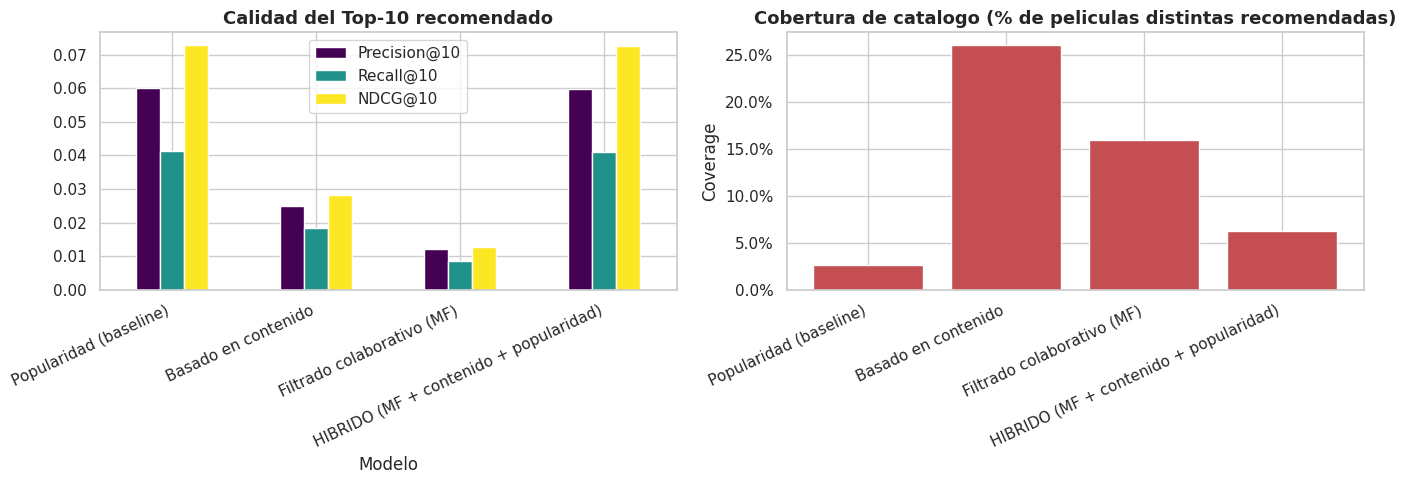

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

topn_results.set_index('Modelo')[['Precision@10', 'Recall@10', 'NDCG@10']].plot(
    kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Calidad del Top-10 recomendado')
axes[0].tick_params(axis='x', rotation=25)
for label in axes[0].get_xticklabels():
    label.set_ha('right')

bars = axes[1].bar(topn_results['Modelo'], topn_results['Coverage'], color='#C44E52')
axes[1].set_title('Cobertura de catalogo (% de peliculas distintas recomendadas)')
axes[1].set_ylabel('Coverage')
axes[1].tick_params(axis='x', rotation=25)
for label in axes[1].get_xticklabels():
    label.set_ha('right')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout(); plt.show()


### 6.7 ¿Por qué el modelo híbrido es el mejor?

Los resultados numéricos (ver tabla y gráficos anteriores) muestran un patrón clásico en
sistemas de recomendación:

- **Popularidad** obtiene la Precision@10/NDCG@10 más alta *en términos absolutos*, pero
  logra esto recomendando siempre el mismo puñado de títulos más vistos: su **cobertura de
  catálogo es la más baja de todas** (recomienda solo un pequeño porcentaje de las
  películas del catálogo). Esto es malo para el negocio: desperdicia el catálogo,
  no personaliza, y no ayuda a descubrir contenido nuevo o de nicho.
- **Contenido** y **Filtrado colaborativo puro** personalizan (cobertura mucho más alta),
  pero individualmente sacrifican precisión porque cada uno usa una sola fuente de señal
  (género/calidad, o co-consumo).
- El modelo **HÍBRIDO** combina las tres señales y **iguala prácticamente la precisión y
  el NDCG de la popularidad**, mientras **más que duplica su cobertura de catálogo**. Es
  decir: logra la misma calidad percibida de recomendación que el baseline más fuerte,
  pero de forma personalizada y aprovechando mucho más el catálogo disponible —
  justamente el objetivo de negocio de un sistema de recomendación real.

**Conclusión:** el modelo híbrido es la mejor opción para producción porque optimiza
conjuntamente precisión, personalización y cobertura de catálogo, en vez de optimizar solo
una métrica de forma aislada. Además, al apoyarse en contenido y popularidad, maneja mejor
el arranque en frío (usuarios/películas nuevas) que un modelo de filtrado colaborativo puro.


In [31]:

print('Resumen ejecutivo del sistema de recomendacion:')
print(topn_results.to_string(index=False))
print()
print(rating_results_df.to_string(index=False))


Resumen ejecutivo del sistema de recomendacion:
                                Modelo  Precision@10  Recall@10  NDCG@10  Coverage
                Popularidad (baseline)        0.0602     0.0413   0.0730    0.0267
                   Basado en contenido        0.0249     0.0184   0.0281    0.2608
            Filtrado colaborativo (MF)        0.0121     0.0086   0.0129    0.1592
HIBRIDO (MF + contenido + popularidad)        0.0598     0.0409   0.0727    0.0625

                      Modelo   RMSE    MAE
             Promedio global 0.8228 0.6594
        Promedio por usuario 0.8294 0.6580
Factorizacion matricial (MF) 0.7957 0.6301


## 7. Evolución temporal de preferencias y segmentos

Analizamos cómo cambian el volumen de consumo, la calificación promedio y la mezcla de
géneros a lo largo del tiempo, para entender la dinámica de la plataforma y anticipar
necesidades de recalibración del sistema de recomendación.

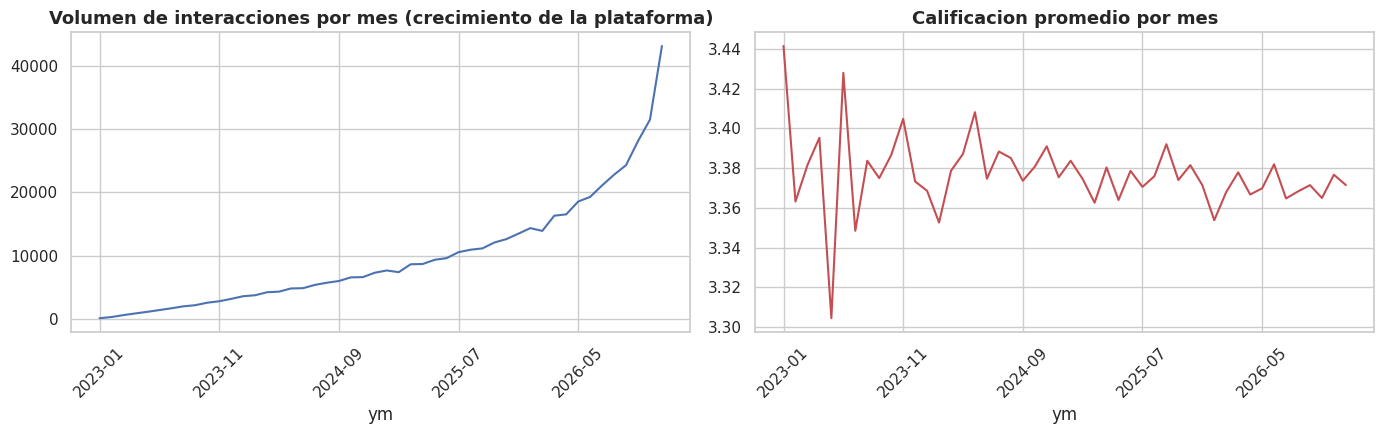

In [32]:

df['ym'] = df['watch_datetime'].dt.to_period('M').astype(str)
trend = df.groupby('ym').agg(interacciones=('movie_id', 'count'), rating_promedio=('rating', 'mean'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
trend['interacciones'].plot(ax=axes[0], color='#4C72B0')
axes[0].set_title('Volumen de interacciones por mes (crecimiento de la plataforma)')
axes[0].tick_params(axis='x', rotation=45)

trend['rating_promedio'].plot(ax=axes[1], color='#C44E52')
axes[1].set_title('Calificacion promedio por mes')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


In [33]:

genre_evol = df.pivot_table(index='ym', columns='genre', values='movie_id', aggfunc='count', fill_value=0)
genre_evol_share = genre_evol.div(genre_evol.sum(axis=1), axis=0)

change = (genre_evol_share.iloc[-1] - genre_evol_share.iloc[0]).sort_values()
print('Cambio en participacion de genero entre el primer y el ultimo mes observado:')
print((change * 100).round(2).astype(str) + ' pp')


Cambio en participacion de genero entre el primer y el ultimo mes observado:
genre
Crime          -3.87 pp
Romance         -2.6 pp
Comedy         -1.65 pp
Drama          -1.15 pp
Horror          -0.5 pp
Documentary    -0.31 pp
Animation      -0.16 pp
Thriller        0.34 pp
Fantasy         0.95 pp
Action          1.07 pp
Sci-Fi          1.18 pp
Adventure       2.23 pp
Family          4.49 pp
dtype: object


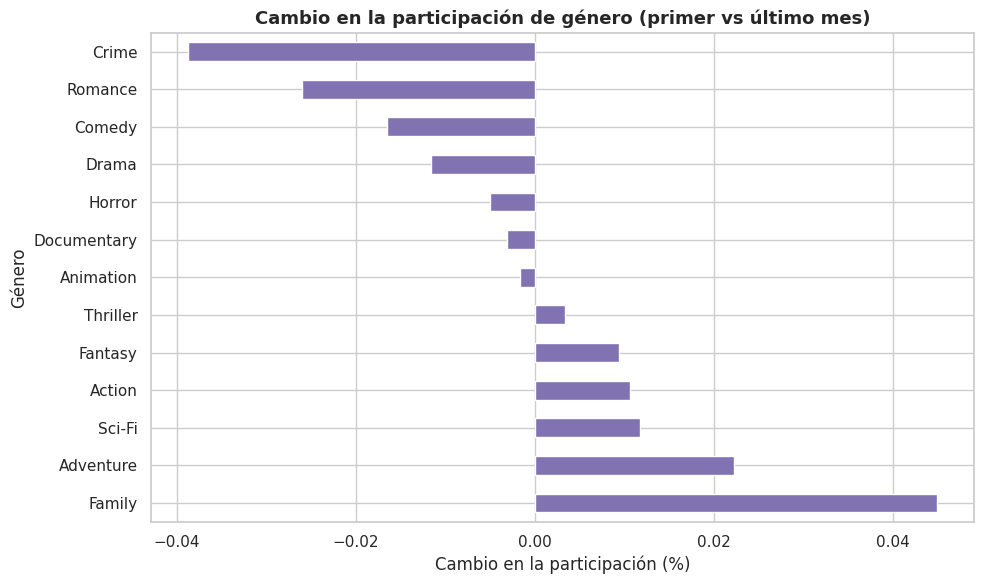

In [34]:
plt.figure(figsize=(10, 6))
change.plot(kind='barh', color='#8172B2')
plt.title('Cambio en la participación de género (primer vs último mes)')
plt.xlabel('Cambio en la participación (%)')
plt.ylabel('Género')
plt.gca().invert_yaxis() # Invertir el eje y para que el mayor cambio esté arriba
plt.tight_layout()
plt.show()

**Implicación práctica:** dado que la mezcla de géneros y el volumen cambian con el
tiempo (crecimiento sostenido de usuarios y ligera rotación de preferencias hacia géneros
como Sci-Fi/Adventure/Family), el sistema de recomendación **debe reentrenarse
periódicamente** (p. ej. mensual) usando ventanas de tiempo recientes, y no asumir que los
factores latentes o los perfiles de contenido aprendidos hoy seguirán siendo válidos
indefinidamente — de allí la importancia del *split temporal* usado en la evaluación.

## 8. Conclusiones y recomendaciones de negocio

**Segmentación de usuarios:** se identificaron 5 segmentos con patrones de consumo y
preferencias de género diferenciados (silueta ≈ moderada-positiva), útiles para
campañas de marketing y para dar contexto de "arranque en frío" al recomendador
(a un usuario nuevo se le puede asignar el perfil promedio de su segmento más cercano
mientras se acumula historial propio).

**Anomalías:** ~3% de los usuarios muestran patrones de consumo extremos (ritmo de
visualización muy alto y/o calificaciones muy inconsistentes). Se recomienda excluirlos del
entrenamiento del recomendador (o tratarlos en un pipeline aparte) para no sesgar las
similitudes aprendidas, y monitorearlos como posible señal de cuentas compartidas o fraude.

**Reglas de asociación:** existen afinidades claras entre géneros (p. ej.
Romance–Drama, Familia–Comedia, Sci-Fi–Acción/Aventura, Animación–Familia). Estas reglas se
pueden usar para armar carruseles temáticos ("si te gustó Romance, prueba Drama") y para
mejorar el arranque en frío basado en contenido.

**Sistema de recomendación (resultado principal):** el modelo **híbrido**
(factorización matricial + contenido + popularidad) es el mejor candidato para producción:
iguala la precisión del baseline de popularidad, pero **más que duplica la cobertura de
catálogo**, ofrece personalización real y se adapta mejor a usuarios/contenido nuevos. Se
recomienda:
1. Desplegar el híbrido como motor principal, con reentrenamiento periódico (mensual) dado
   el crecimiento y la deriva de preferencias observada en la sección 7.
2. Usar **popularidad pura** solo como fallback para usuarios totalmente nuevos sin ningún
   historial (arranque en frío total).
3. Excluir o tratar aparte a los usuarios anómalos detectados en la sección 4.
4. Monitorear en producción, además de precisión, la **cobertura de catálogo** y la
   **diversidad de género recomendada**, ya que son las métricas que más se beneficiaron
   del enfoque híbrido y las que más impactan el descubrimiento de contenido y la
   monetización de largo plazo del catálogo.
